# Clasificador de Galaxias con Anillos — Zoobot v7 (Binario)
## — none vs ring — 
### Cambios clave vs v5/v6:
1. **Clasificación BINARIA** (none vs ring) — fusiona inner+outer+inner+outer en "ring"
2. **Subsampleo de "none"** a 1500 en vez de oversamplear ring — ratio ~1:1
3. **BCEWithLogitsLoss** — más estable que CrossEntropy/FocalLoss para binario
4. **Búsqueda de umbral óptimo** — barre 99 thresholds para maximizar Ring F1
5. **ReduceLROnPlateau** — reduce LR cuando F1 se estanca (en vez de CosineAnnealing)
6. **Zoobot encoder** mantenido — preentrenado en Galaxy Zoo, ideal para galaxias
7. **Head simple** — encoder_dim → 128 → 1 (menos overfitting)

| Clase | Descripción |
|-------|------------|
| none | Sin anillo |
| ring | Con anillo (inner, outer, o ambos) |


---
# Parte 1: Instalación y configuración

> **Nota:** Ejecutar esta celda solo la primera vez o si falta algún paquete.
> Después de instalar Zoobot, **reinstalar PyTorch con CUDA** si tienes GPU.

In [1]:
'''
# ============================================================
# Instalación de dependencias
# ============================================================
# 1. Instalar Zoobot (puede sobreescribir PyTorch CPU-only)
!pip install zoobot

# 2. IMPORTANTE: Reinstalar PyTorch con CUDA para tu GPU
#    Ajusta cu126 a tu versión de CUDA (nvcc --version)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

# 3. Dependencias adicionales
!pip install timm plotly nbformat opencv-python-headless pytorch-grad-cam

# Verificar CUDA
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
'''
print("Celda de instalación (descomenta para ejecutar)")

Celda de instalación (descomenta para ejecutar)


---
# Parte 2: Imports globales

In [2]:
# ============================================================
# Imports
# ============================================================
import os
import io
import re
import cv2
import time
import glob
import shutil
import random
import pathlib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from astropy.io import fits
from astropy.visualization import (
    make_lupton_rgb, ZScaleInterval, MinMaxInterval, LogStretch
)

from scipy import ndimage
from scipy.signal import find_peaks, peak_prominences, savgol_filter
from skimage import filters, measure, morphology, segmentation
from skimage.draw import ellipse_perimeter
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.morphology import (
    binary_closing, binary_dilation, binary_erosion, binary_opening, disk
)

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score, roc_curve
)

import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from matplotlib.patches import Ellipse

import timm

import requests

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

print("Imports completados exitosamente")

Imports completados exitosamente


---
# Parte 3: Configuración global

> **⚠️ ADAPTAR:** Modifica las rutas a tus archivos y directorios según tu entorno.

In [3]:
# ============================================================
# CONFIGURACIÓN — ADAPTAR RUTAS AQUÍ
# ============================================================

# --- Rutas de entrada ---
CSV_DATASET      = "../Dataset/dataset.csv"
CSV_MANGA        = "../Dataset/MaNGA_rings.csv"
CSV_CSRG         = "../Dataset/CSRG_Buta.csv"
FITS_GRZ_DIR     = Path("../Images_GRZ")

# --- Rutas de salida ---
DATA_DIR         = Path("./galaxy_images")
OUTPUT_DIR       = Path("./outputs")
DATASET_NAME     = "dataset_zoobot_4cls"

# --- Parámetros de imagen ---
PIXSCALE  = 0.262           # arcsec/pixel (Legacy Survey)
SIZE      = 224
BANDS     = "grz"

# --- Transformación FITS → PNG ---
TRANSFORM = "rgi_lognorm"

# --- Legacy Survey ---
LAYER     = "ls-dr10"
TIMEOUT_S = 60
WORKERS   = 8
SLEEP_S   = 0.05

# --- Clases (4 clases principales) ---
# v7: Clasificación BINARIA (none vs ring) — mucho más efectivo
# Los 4 tipos de anillo se fusionan en una sola clase "ring"
RING_CODES_ORIGINAL = {0: "none", 4: "inner", 8: "outer", 12: "inner+outer"}
RING_CODES = {0: "none", 4: "ring", 8: "ring", 12: "ring"}
RING_TYPE  = ["none", "ring"]  # Binario
ANILLOS_LABEL = RING_CODES
VALID_CODES   = {0, 4, 8, 12}

# --- Entrenamiento ---
BATCH_SIZE    = 64
IMAGE_SIZE    = 224
SEED          = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Constantes morfológicas ---
PLATE_SCALE = PIXSCALE

# Crear directorios
for d in [DATA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
for cls_name in RING_TYPE:
    (DATA_DIR / cls_name).mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = "download_log.csv"

print(f"Device: {DEVICE}")
print(f"Clases: {RING_TYPE}")
print(f"FITS GRZ dir: {FITS_GRZ_DIR}")

Device: cuda
Clases: ['none', 'ring']
FITS GRZ dir: ..\Images_GRZ


---
# Parte 4: Funciones auxiliares

## 4.1 Utilidades de conversión y URLs

In [4]:
def to_int(x, default=0):
    """Convierte un valor a entero de forma segura."""
    try:
        return int(float(x))
    except Exception:
        return default

def legacy_cutout_url(ra, dec, pixscale=PIXSCALE, size=SIZE, bands=BANDS, layer=LAYER):
    return (f"https://www.legacysurvey.org/viewer/fits-cutout"
            f"?ra={ra}&dec={dec}&layer={layer}"
            f"&pixscale={pixscale}&size={size}&bands={bands}")

def legacy_jpg_url(ra, dec, pixscale=PIXSCALE, size=SIZE, layer=LAYER):
    return (f"https://www.legacysurvey.org/viewer/cutout.jpg"
            f"?ra={ra}&dec={dec}&layer={layer}"
            f"&pixscale={pixscale}&size={size}")

print("Utilidades cargadas")

Utilidades cargadas


## 4.2 Transformaciones de imagen FITS → RGB

Se implementan múltiples transformaciones para procesar las imágenes astronómicas de 3 bandas:
- **RGI Stack**: Composición directa r, g, z → RGB
- **RGI LogNorm**: Normalización logarítmica suave (recomendada)
- **Unsharp**: Realce de bordes por enmascaramiento de enfoque
- **PCA**: Reducción de dimensionalidad para maximizar contraste
- **Log N Scale**: Escalado logarítmico clásico

In [5]:
class Transformations:
    @staticmethod
    def log_n_scale_transform(img_data, log_a=1000, clip_mode='minmax', med_val=20):
        if img_data is None or img_data.size == 0:
            return None
        img = img_data.astype(np.float64)
        if clip_mode == 'median':
            vmin = max(np.nanmedian(img) - med_val, 0)
            vmax = np.nanpercentile(img, 99.9)
        else:
            vmin, vmax = np.nanpercentile(img, [0.5, 99.5])
        img = np.clip(img, vmin, vmax)
        if vmax > vmin:
            img = (img - vmin) / (vmax - vmin)
        img = np.log10(1 + log_a * img) / np.log10(1 + log_a)
        return np.clip(img * 255, 0, 255).astype(np.uint8)

    @staticmethod
    def rgi_stack_transform(r, g, z):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            channels.append((b * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def rgi_lognorm_transform(r, g, z, log_a=1000):
        channels = []
        for band in [r, g, z]:
            ch = Transformations.log_n_scale_transform(band, log_a=log_a)
            if ch is None:
                return None
            channels.append(ch)
        return np.stack(channels, axis=-1)

    @staticmethod
    def unsharp_transform(r, g, z, sigma=5, strength=2.0):
        channels = []
        for band in [r, g, z]:
            b = band.astype(np.float64)
            p1, p99 = np.nanpercentile(b, [1, 99])
            b = np.clip(b, p1, p99)
            b = (b - p1) / max(p99 - p1, 1e-10)
            blurred = gaussian(b, sigma=sigma)
            sharp = b + strength * (b - blurred)
            sharp = np.clip(sharp, 0, 1)
            channels.append((sharp * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def pca_transform(r, g, z):
        bands = np.stack([r.flatten(), g.flatten(), z.flatten()], axis=1).astype(np.float64)
        bands -= bands.mean(axis=0)
        cov = np.cov(bands, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        idx = eigenvalues.argsort()[::-1]
        eigenvectors = eigenvectors[:, idx]
        pca = bands @ eigenvectors
        channels = []
        for i in range(3):
            ch = pca[:, i].reshape(r.shape)
            p1, p99 = np.nanpercentile(ch, [1, 99])
            ch = np.clip(ch, p1, p99)
            ch = (ch - p1) / max(p99 - p1, 1e-10)
            channels.append((ch * 255).astype(np.uint8))
        return np.stack(channels, axis=-1)

    @staticmethod
    def apply_transform(r_band, g_band, z_band, method="rgi_lognorm"):
        methods = {
            "rgi_stack":    lambda: Transformations.rgi_stack_transform(r_band, g_band, z_band),
            "rgi_lognorm":  lambda: Transformations.rgi_lognorm_transform(r_band, g_band, z_band),
            "unsharp":      lambda: Transformations.unsharp_transform(r_band, g_band, z_band),
            "pca":          lambda: Transformations.pca_transform(r_band, g_band, z_band),
            "log_n_scale":  lambda: Transformations.rgi_lognorm_transform(r_band, g_band, z_band, log_a=500),
        }
        if method not in methods:
            print(f"Método desconocido: {method}, usando rgi_lognorm")
            method = "rgi_lognorm"
        try:
            return methods[method]()
        except Exception as e:
            print(f"Error en transformación {method}: {e}")
            return None

print("Transformaciones cargadas")

Transformaciones cargadas


---
# Parte 5: Construcción del dataset

## 5.1 Carga y filtrado de catálogos

Se cargan los catálogos disponibles y se filtran las 4 clases de interés.

> **Nota sobre clases 2 y 16:** El dataset original contiene códigos 2 (111 galaxias)
> y 16 (342 galaxias) que no están en la tabla de clasificación estándar de 4 clases.
> Estas se excluyen del entrenamiento pero se documentan en el EDA.

In [6]:
# ============================================================
# Cargar catálogo y mapear objID → clase BINARIA
# ============================================================
df_sdss = pd.read_csv(CSV_DATASET)
df_sdss['objID'] = df_sdss['objID'].astype(np.int64)
print(f"Catálogo — Filas: {len(df_sdss)}")

# Distribución original
print("\nDistribución original:")
for code in sorted(df_sdss['anillos'].unique()):
    n = (df_sdss['anillos'] == code).sum()
    print(f"  código {int(code):3d}: {n:5d} galaxias")

# Filtrar y mapear a binario: 0→none, 4/8/12→ring
df_sdss['anillos_int'] = df_sdss['anillos'].apply(lambda x: to_int(x, -1))
df_sdss = df_sdss[df_sdss['anillos_int'].isin(VALID_CODES)].copy()
df_sdss['ring_type'] = df_sdss['anillos_int'].map(RING_CODES)

print(f"\nTras mapeo binario: {len(df_sdss)} galaxias")
print(df_sdss['ring_type'].value_counts())
print(f"\nRatio none:ring = {(df_sdss.ring_type=='none').sum() / (df_sdss.ring_type=='ring').sum():.1f}:1")

objid_to_class = dict(zip(df_sdss['objID'], df_sdss['ring_type']))

# MaNGA
try:
    df_manga = pd.read_csv(CSV_MANGA)
    df_manga['anillos_int'] = df_manga['anillos'].apply(lambda x: to_int(x, -1))
    df_manga = df_manga[df_manga['anillos_int'].isin(VALID_CODES)].copy()
    df_manga['ring_type'] = df_manga['anillos_int'].map(RING_CODES)
    print(f"\nMaNGA — {len(df_manga)} galaxias")
except FileNotFoundError:
    print("\nMaNGA no encontrado")


Catálogo — Filas: 8528

Distribución original:
  código   0:  6660 galaxias
  código   2:   111 galaxias
  código   4:   857 galaxias
  código   8:   186 galaxias
  código  12:   372 galaxias
  código  16:   342 galaxias

Tras mapeo binario: 8075 galaxias
ring_type
none    6660
ring    1415
Name: count, dtype: int64

Ratio none:ring = 4.7:1

MaNGA — 680 galaxias


## 5.2 Procesar FITS locales (Images_GRZ) → PNG por clase

Lee los archivos FITS de 3 bandas (g, r, z) de tu carpeta local,
aplica la transformación seleccionada y guarda como PNG organizado por clase.

In [7]:
# ============================================================
# PROCESAR FITS LOCALES (Images_GRZ) → PNG por clase
# ============================================================
fits_files = sorted(FITS_GRZ_DIR.glob("*_grz.fits"))
print(f"FITS encontrados en {FITS_GRZ_DIR}: {len(fits_files)}")

if len(fits_files) == 0:
    print("  No se encontraron archivos *_grz.fits")
    print(f"   Verifica la ruta: {FITS_GRZ_DIR.resolve()}")
else:
    processed, skipped_no_class, skipped_exists, errors = 0, 0, 0, 0

    for fits_path in fits_files:
        try:
            objid = int(fits_path.stem.replace("_grz", ""))
            if objid not in objid_to_class:
                skipped_no_class += 1
                continue

            ring_class = objid_to_class[objid]
            dest_png = DATA_DIR / ring_class / f"{objid}_{ring_class}.png"

            if dest_png.exists() and dest_png.stat().st_size > 0:
                skipped_exists += 1
                processed += 1
                continue

            with fits.open(fits_path) as hdul:
                data = hdul[0].data
                if data is None or data.ndim < 3:
                    errors += 1
                    continue
                g_band, r_band, z_band = data[0], data[1], data[2]
                img = Transformations.apply_transform(r_band, g_band, z_band, TRANSFORM)

                if img is not None:
                    pil_img = Image.fromarray(img)
                    if pil_img.size != (IMAGE_SIZE, IMAGE_SIZE):
                        pil_img = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
                    pil_img.save(dest_png)
                    processed += 1
                else:
                    errors += 1
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f"  Error en {fits_path.name}: {e}")

        total = processed + skipped_no_class + errors
        if total % 2000 == 0 and total > 0:
            print(f"  Progreso: {total}/{len(fits_files)}")

    print(f"\n{'='*50}")
    print(f"RESULTADO:")
    print(f"  Procesados:     {processed} ({skipped_exists} ya existían)")
    print(f"  Sin clase CSV:  {skipped_no_class}")
    print(f"  Errores:        {errors}")
    print(f"\nImágenes por clase:")
    total_imgs = 0
    for cls_name in RING_TYPE:
        n = len(list((DATA_DIR / cls_name).glob("*.png")))
        total_imgs += n
        print(f"  {cls_name:15s}: {n}")
    print(f"  TOTAL:           {total_imgs}")

FITS encontrados en ..\Images_GRZ: 7678



RESULTADO:
  Procesados:     7247 (5918 ya existían)
  Sin clase CSV:  431
  Errores:        0

Imágenes por clase:
  none           : 5918
  ring           : 1329
  TOTAL:           7247


---
# Parte 6: Análisis Exploratorio de Datos (EDA)

## 6.1 Distribución de clases

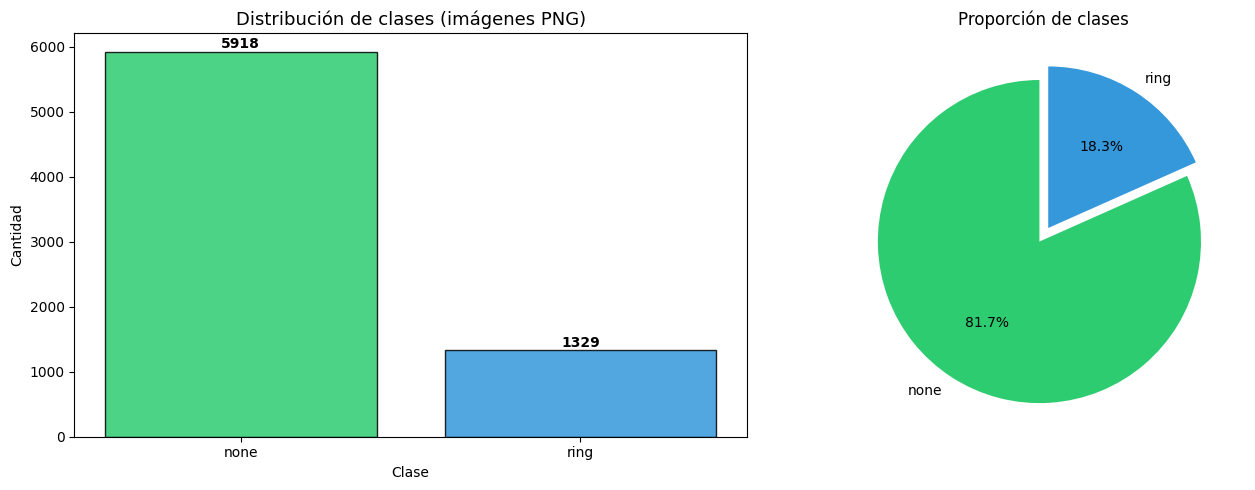


Ratio de desbalanceo: 4.5:1
Estrategia: WeightedRandomSampler + FocalLoss para compensar


In [9]:
# ============================================================
# Distribución de clases
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
counts = {cls: len(list((DATA_DIR / cls).glob("*.png"))) for cls in RING_TYPE}
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'][:len(counts)]
bars = axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor='black', alpha=0.85)
for bar, count in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_title("Distribución de clases (imágenes PNG)", fontsize=13)
axes[0].set_ylabel("Cantidad")
axes[0].set_xlabel("Clase")

# Pie chart con proporciones
axes[1].pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
           colors=colors, startangle=90, explode=[0.05]*len(counts))
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.show()

# Ratio de desbalanceo
max_cls = max(counts.values())
min_cls = min(counts.values())
print(f"\nRatio de desbalanceo: {max_cls/min_cls:.1f}:1")
print("Estrategia: WeightedRandomSampler + FocalLoss para compensar")

## 6.2 Visualización de muestras por clase

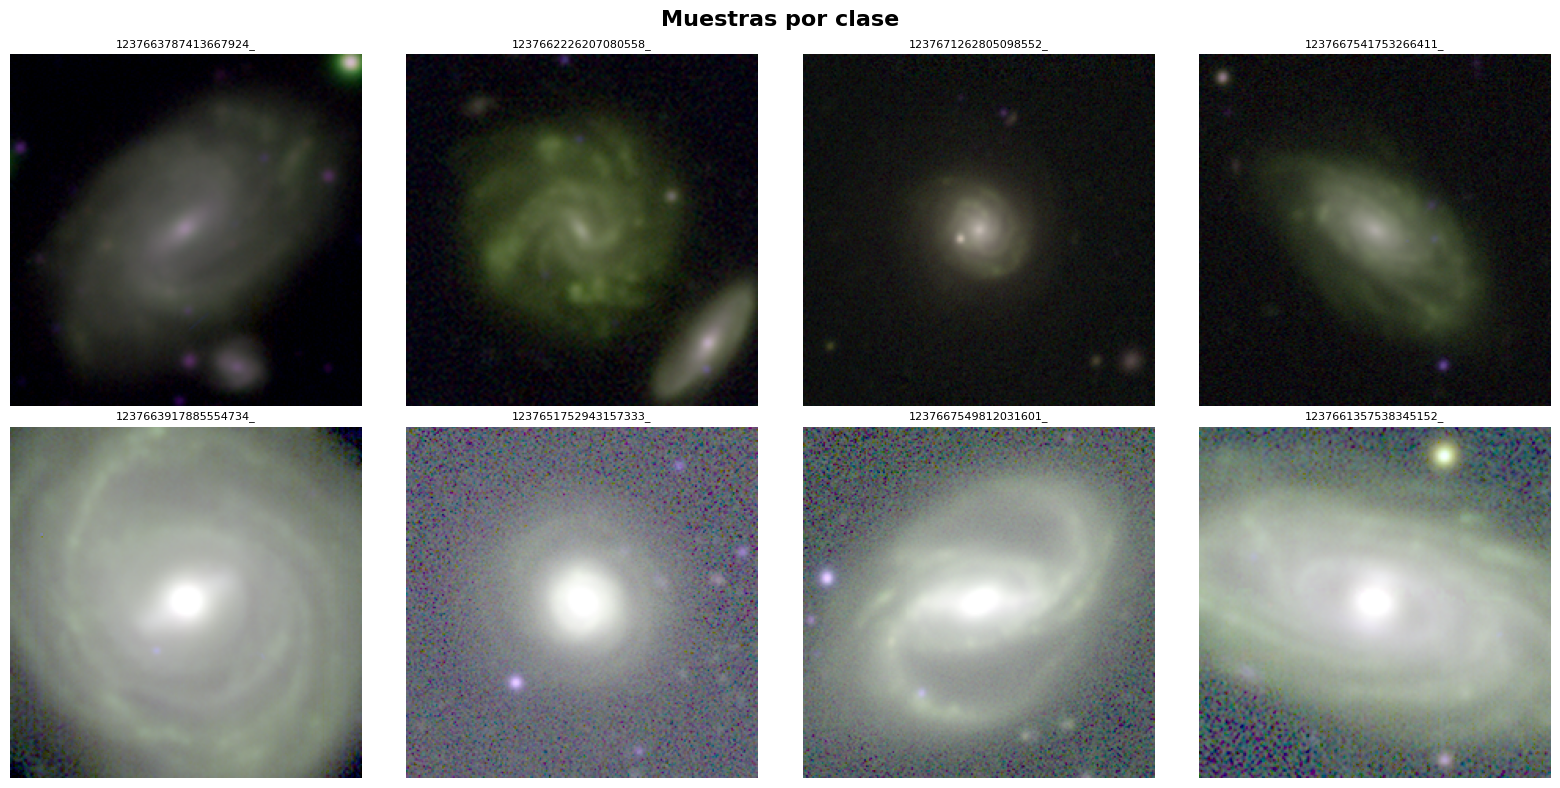

In [10]:
def plot_samples_by_class(data_dir, ring_types, samples_per_class=4):
    """Visualiza muestras aleatorias de cada clase."""
    fig, axs = plt.subplots(len(ring_types), samples_per_class,
                           figsize=(4*samples_per_class, 4*len(ring_types)))
    for i, cls in enumerate(ring_types):
        cls_dir = Path(data_dir) / cls
        imgs = list(cls_dir.glob("*.png"))
        if not imgs:
            continue
        samples = random.sample(imgs, min(samples_per_class, len(imgs)))
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axs[i, j].imshow(img)
            axs[i, j].axis("off")
            if j == 0:
                axs[i, j].set_ylabel(cls, fontsize=14, fontweight='bold', rotation=0,
                                    labelpad=60, va='center')
            axs[i, j].set_title(img_path.stem[:20], fontsize=8)
    plt.suptitle("Muestras por clase", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_samples_by_class(DATA_DIR, RING_TYPE)

---
# Parte 8: Preparación del dataset para entrenamiento

## 8.1 Split train/val y organización de carpetas

In [11]:
# ============================================================
# Split train/val + SUBSAMPLEAR "none" para equilibrar
# ============================================================
# Estrategia: en vez de copiar ring 30x (oversampling),
# reducimos none a ~1500 para lograr ratio ~1:1
# Esto es más efectivo porque evita overfitting a copias repetidas.

def create_dataset_folders(base_path, categories):
    base_path = Path(base_path)
    for split in ['train', 'val']:
        for cat in categories:
            (base_path / split / cat).mkdir(parents=True, exist_ok=True)

def split_and_subsample(source_dir, dest_base, categories, 
                         val_fraction=0.2, seed=42, max_per_class=1500):
    """Split + subsamplear clase mayoritaria."""
    random.seed(seed)
    np.random.seed(seed)
    create_dataset_folders(dest_base, categories)

    for cat in categories:
        src = Path(source_dir) / cat
        imgs = sorted(src.glob("*.png"))
        random.shuffle(imgs)
        
        # Subsamplear si excede max_per_class
        if len(imgs) > max_per_class:
            print(f"  {cat:8s}: {len(imgs)} → subsampled to {max_per_class}")
            imgs = imgs[:max_per_class]
        
        n_val = max(10, int(len(imgs) * val_fraction))
        val_imgs = imgs[:n_val]
        train_imgs = imgs[n_val:]

        for img in train_imgs:
            shutil.copy2(img, Path(dest_base) / "train" / cat / img.name)
        for img in val_imgs:
            shutil.copy2(img, Path(dest_base) / "val" / cat / img.name)

        print(f"  {cat:8s}: {len(train_imgs)} train, {len(val_imgs)} val")

# Limpiar split anterior
if Path(DATASET_NAME).exists():
    shutil.rmtree(DATASET_NAME)

print("Creando dataset binario balanceado...")
split_and_subsample(DATA_DIR, DATASET_NAME, RING_TYPE, max_per_class=1500)

print("\nVerificación:")
for split in ['train', 'val']:
    for cat in RING_TYPE:
        n = len(list(Path(f"{DATASET_NAME}/{split}/{cat}").glob("*.png")))
        print(f"  {split}/{cat}: {n}")


Creando dataset binario balanceado...
  none    : 5918 → subsampled to 1500
  none    : 1200 train, 300 val
  ring    : 1064 train, 265 val

Verificación:
  train/none: 1200
  train/ring: 1064
  val/none: 300
  val/ring: 265


## 8.2 Dataset personalizado con augmentation y balanceo

In [12]:
class GalaxyDataset(Dataset):
    """Dataset simple para clasificación binaria."""

    def __init__(self, root_dir, categories, transform=None, balance=True, target_count=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.labels = []
        self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
        self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}

        class_files = {cat: list(self.root_dir.glob(f"{cat}/*.png")) for cat in categories}
        
        if balance and target_count is None:
            target_count = max(len(f) for f in class_files.values())
        
        for cat, files in class_files.items():
            if balance and len(files) < target_count:
                extra = list(np.random.choice(files, target_count - len(files), replace=True))
                files = files + extra
            self.samples.extend(files)
            self.labels.extend([self.class_to_idx[cat]] * len(files))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

    def __repr__(self):
        counts = defaultdict(int)
        for lbl in self.labels:
            counts[self.idx_to_class[lbl]] += 1
        return f"GalaxyDataset({len(self)} samples: {dict(counts)})"

print("GalaxyDataset definido")


GalaxyDataset definido


## 8.3 Definir transformaciones y DataLoaders

In [13]:
# ============================================================
# Augmentaciones + DataLoaders
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=20, translate=(0.05, 0.05),
                            scale=(0.9, 1.1), shear=5, fill=0),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
    transforms.RandomRotation(180, fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = GalaxyDataset(f'{DATASET_NAME}/train', RING_TYPE,
                               transform=train_transform, balance=True)
val_dataset = GalaxyDataset(f'{DATASET_NAME}/val', RING_TYPE,
                             transform=val_transform, balance=False)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train:", train_dataset)
print("Val:", val_dataset)


Train: GalaxyDataset(2400 samples: {'none': 1200, 'ring': 1200})
Val: GalaxyDataset(565 samples: {'none': 300, 'ring': 265})


---
# Parte 9: Fine-tuning de Zoobot

## 9.1 Fundamento teórico

**Zoobot** es un modelo preentrenado en millones de clasificaciones de Galaxy Zoo (Walmsley et al. 2023).
Usamos el encoder ConvNeXT-Nano como backbone y le añadimos un head personalizado.

### Mejoras en v5:
- **Head más profundo**: 2 capas lineales (encoder_dim → 512 → 4) con BatchNorm + Dropout
- **FocalLoss** con gamma=2.0 y label smoothing=0.05 para clases desbalanceadas
- **Mixup** (alpha=0.3) en fases 2 y 3 para regularización
- **CosineAnnealing** con warm restarts para learning rate

## 9.2 Modelo basado en Zoobot

In [14]:
# ============================================================
# Loss y utilidades — BCEWithLogitsLoss para binario
# ============================================================
# BCEWithLogitsLoss es más estable que CrossEntropy para 2 clases
# porque opera directamente sobre el logit (sin softmax)

print("BCEWithLogitsLoss será usado dentro del modelo")


BCEWithLogitsLoss será usado dentro del modelo


In [15]:
# ============================================================
# Zoobot Binary Classifier v7
# ============================================================
# Cambios clave vs v5/v6:
# - Salida binaria: 1 neurona + BCEWithLogitsLoss
# - Búsqueda de umbral óptimo en evaluación
# - ReduceLROnPlateau (monitorea F1) en vez de CosineAnnealing
# - Head simple: encoder_dim → 128 → 1

class ZoobotBinaryClassifier(nn.Module):
    def __init__(self, dropout=0.4,
                 encoder_name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano'):
        super().__init__()
        self.device = DEVICE
        self.ring_type = RING_TYPE  # ["none", "ring"]

        print(f"Cargando encoder: {encoder_name}")
        self.encoder = timm.create_model(encoder_name, pretrained=True, num_classes=0)

        with torch.no_grad():
            dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            encoder_dim = self.encoder(dummy).shape[-1]
        print(f"Encoder dim: {encoder_dim}")

        # Head binario: simple y efectivo
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(encoder_dim, 128),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, 1),  # 1 salida para binario
        )

        self.criterion = nn.BCEWithLogitsLoss()
        self.best_threshold = 0.5
        self.to(self.device)

    def forward(self, x):
        features = self.encoder(x)
        if features.dim() > 2:
            features = F.adaptive_avg_pool2d(features, 1).flatten(1)
        return self.head(features).squeeze(1)  # Shape: (batch,)

    def save_model(self, path):
        torch.save({'state_dict': self.state_dict(),
                    'best_threshold': self.best_threshold}, path)
        print(f"Modelo guardado: {path}")

    def load_model(self, path):
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        if isinstance(ckpt, dict) and 'state_dict' in ckpt:
            self.load_state_dict(ckpt['state_dict'])
            self.best_threshold = ckpt.get('best_threshold', 0.5)
        else:
            self.load_state_dict(ckpt)
        print(f"Modelo cargado: {path} (threshold={self.best_threshold:.2f})")

    def __str__(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return (f"ZoobotBinaryClassifier v7\n"
                f"  Classes: {self.ring_type}\n"
                f"  Params: {total:,} total, {trainable:,} trainable\n"
                f"  Loss: BCEWithLogitsLoss | Threshold: {self.best_threshold:.2f}")

    def set_phase(self, phase):
        for param in self.parameters():
            param.requires_grad = False

        if phase >= 1:
            for param in self.head.parameters():
                param.requires_grad = True

        if phase >= 2:
            for child in list(self.encoder.children())[-2:]:
                for param in child.parameters():
                    param.requires_grad = True

        if phase >= 3:
            for param in self.encoder.parameters():
                param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        phase_names = {1: "Head only", 2: "Head + last encoder layers", 3: "Full model"}
        print(f"  Phase {phase} ({phase_names.get(phase, '?')}): {trainable:,}/{total:,} params ({100*trainable/total:.1f}%)")

    def _find_best_threshold(self, probs, labels):
        """Barre umbrales para maximizar F1 de la clase 'ring'."""
        best_f1, best_th = 0, 0.5
        for th in np.linspace(0.01, 0.99, 99):
            preds = (probs >= th).astype(int)
            f1 = f1_score(labels, preds, pos_label=1, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_th = th
        return best_th, best_f1

    def _validate(self, val_loader):
        """Validación con búsqueda de umbral óptimo."""
        self.eval()
        all_probs, all_labels = [], []
        running_loss, total = 0.0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(self.device), labels.float().to(self.device)
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                total += images.size(0)
                probs = torch.sigmoid(outputs).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(labels.cpu().numpy())

        probs_arr = np.array(all_probs)
        labels_arr = np.array(all_labels)

        best_th, ring_f1 = self._find_best_threshold(probs_arr, labels_arr)
        preds = (probs_arr >= best_th).astype(int)
        acc = (preds == labels_arr).mean()

        return {"loss": running_loss / total, "acc": float(acc),
                "ring_f1": float(ring_f1), "threshold": float(best_th)}

    def train_model(self, train_loader, val_loader, epochs=15, phase=1, lr=1e-4, patience=8):
        self.to(self.device)
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "ring_f1": []}

        print(f"\n{'='*60}")
        print(f" Phase {phase} — {epochs} epochs | LR={lr}")
        print(f"{'='*60}")
        self.set_phase(phase)

        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=lr, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7
        )

        best_f1 = 0.0
        patience_counter = 0

        for epoch in range(epochs):
            self.train()
            running_loss, correct, total = 0.0, 0, 0

            for images, labels in train_loader:
                images = images.to(self.device)
                labels = labels.float().to(self.device)

                optimizer.zero_grad()
                outputs = self(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                optimizer.step()

                running_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).long()
                correct += (preds == labels.long()).sum().item()
                total += labels.size(0)

            e_loss = running_loss / total
            e_acc = correct / total
            history["train_loss"].append(e_loss)
            history["train_acc"].append(e_acc)

            # Validación con threshold search
            val_m = self._validate(val_loader)
            history["val_loss"].append(val_m["loss"])
            history["val_acc"].append(val_m["acc"])
            history["ring_f1"].append(val_m["ring_f1"])

            # ReduceLROnPlateau monitorea ring F1
            scheduler.step(val_m["ring_f1"])
            lr_now = optimizer.param_groups[0]['lr']

            print(f"  E{epoch+1:02d}/{epochs} | TL {e_loss:.4f} TA {e_acc:.3f} | "
                  f"VL {val_m['loss']:.4f} VA {val_m['acc']:.3f} | "
                  f"RF1 {val_m['ring_f1']:.4f} th={val_m['threshold']:.2f} | lr {lr_now:.2e}")

            if val_m["ring_f1"] > best_f1:
                best_f1 = val_m["ring_f1"]
                self.best_threshold = val_m["threshold"]
                self.save_model(f"best_zoobot_v7_phase{phase}_f1{best_f1*100:.0f}.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"  Early stopping (patience={patience})")
                    break

        return history

    def evaluate(self, val_loader, plot=True):
        """Evaluación final con threshold óptimo."""
        self.eval()
        all_probs, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(self.device)
                outputs = self(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(labels.numpy())

        probs_arr = np.array(all_probs)
        labels_arr = np.array(all_labels)

        # Buscar mejor threshold
        best_th, best_ring_f1 = self._find_best_threshold(probs_arr, labels_arr)
        self.best_threshold = best_th
        preds = (probs_arr >= best_th).astype(int)

        print(f"\nBest threshold: {best_th:.2f}")
        print(f"Ring F1: {best_ring_f1:.4f}")
        print("\n" + "="*60)
        report = classification_report(labels_arr, preds, target_names=self.ring_type)
        print(report)
        report_dict = classification_report(labels_arr, preds, 
                                           target_names=self.ring_type, output_dict=True)

        if plot:
            fig, axes = plt.subplots(1, 3, figsize=(20, 5))

            # Confusion matrix
            cm = confusion_matrix(labels_arr, preds)
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=self.ring_type,
                       yticklabels=self.ring_type, cmap='Blues', ax=axes[0])
            axes[0].set_title(f'Confusion Matrix (th={best_th:.2f})')
            axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

            # Normalized
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=self.ring_type,
                       yticklabels=self.ring_type, cmap='YlOrRd', ax=axes[1])
            axes[1].set_title('Normalized')

            # F1 vs threshold curve
            ths = np.linspace(0.01, 0.99, 99)
            f1s = [f1_score(labels_arr, (probs_arr >= t).astype(int), pos_label=1, zero_division=0) for t in ths]
            axes[2].plot(ths, f1s, 'b-', linewidth=2)
            axes[2].axvline(best_th, color='r', linestyle='--', label=f'Best th={best_th:.2f}')
            axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Ring F1')
            axes[2].set_title('F1 vs Threshold'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

            plt.tight_layout(); plt.show()

        return report_dict


# Instanciar
model = ZoobotBinaryClassifier(dropout=0.4)
print(model)


Cargando encoder: hf_hub:mwalmsley/zoobot-encoder-convnext_nano


Encoder dim: 640
ZoobotBinaryClassifier v7
  Classes: ['none', 'ring']
  Params: 15,034,737 total, 15,034,737 trainable
  Loss: BCEWithLogitsLoss | Threshold: 0.50


## 9.3 Entrenamiento progresivo (3 fases)

In [16]:
# Fase 1: Solo Head (15 épocas)
history_f1 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=1, lr=1e-3, patience=8)



 Phase 1 — 15 epochs | LR=0.001
  Phase 1 (Head only): 82,177/15,034,737 params (0.5%)
  E01/15 | TL 0.0763 TA 0.972 | VL 0.0050 VA 1.000 | RF1 1.0000 th=0.72 | lr 1.00e-03
Modelo guardado: best_zoobot_v7_phase1_f1100.pt
  E02/15 | TL 0.0151 TA 0.996 | VL 0.0031 VA 1.000 | RF1 1.0000 th=0.06 | lr 1.00e-03
  E03/15 | TL 0.0164 TA 0.995 | VL 0.0006 VA 1.000 | RF1 1.0000 th=0.10 | lr 1.00e-03
  E04/15 | TL 0.0105 TA 0.996 | VL 0.0014 VA 1.000 | RF1 1.0000 th=0.35 | lr 1.00e-03
  E05/15 | TL 0.0088 TA 0.997 | VL 0.0006 VA 1.000 | RF1 1.0000 th=0.01 | lr 1.00e-03
  E06/15 | TL 0.0066 TA 0.998 | VL 0.0003 VA 1.000 | RF1 1.0000 th=0.08 | lr 5.00e-04
  E07/15 | TL 0.0041 TA 0.999 | VL 0.0008 VA 1.000 | RF1 1.0000 th=0.29 | lr 5.00e-04
  E08/15 | TL 0.0039 TA 0.998 | VL 0.0005 VA 1.000 | RF1 1.0000 th=0.19 | lr 5.00e-04
  E09/15 | TL 0.0074 TA 0.998 | VL 0.0021 VA 1.000 | RF1 1.0000 th=0.55 | lr 5.00e-04
  Early stopping (patience=8)


In [17]:
# Fase 2: Head + últimas capas encoder (15 épocas)
history_f2 = model.train_model(train_dataloader, val_dataloader,
    epochs=15, phase=2, lr=1e-4, patience=8)



 Phase 2 — 15 epochs | LR=0.0001
  Phase 2 (Head + last encoder layers): 83,457/15,034,737 params (0.6%)
  E01/15 | TL 0.0021 TA 1.000 | VL 0.0009 VA 1.000 | RF1 1.0000 th=0.32 | lr 1.00e-04
Modelo guardado: best_zoobot_v7_phase2_f1100.pt
  E02/15 | TL 0.0035 TA 0.999 | VL 0.0024 VA 1.000 | RF1 1.0000 th=0.62 | lr 1.00e-04
  E03/15 | TL 0.0054 TA 0.998 | VL 0.0001 VA 1.000 | RF1 1.0000 th=0.04 | lr 1.00e-04
  E04/15 | TL 0.0039 TA 0.999 | VL 0.0003 VA 1.000 | RF1 1.0000 th=0.11 | lr 1.00e-04
  E05/15 | TL 0.0043 TA 0.998 | VL 0.0004 VA 1.000 | RF1 1.0000 th=0.18 | lr 1.00e-04
  E06/15 | TL 0.0033 TA 0.999 | VL 0.0004 VA 1.000 | RF1 1.0000 th=0.18 | lr 5.00e-05
  E07/15 | TL 0.0018 TA 1.000 | VL 0.0004 VA 1.000 | RF1 1.0000 th=0.15 | lr 5.00e-05
  E08/15 | TL 0.0035 TA 0.999 | VL 0.0005 VA 1.000 | RF1 1.0000 th=0.20 | lr 5.00e-05
  E09/15 | TL 0.0053 TA 0.998 | VL 0.0005 VA 1.000 | RF1 1.0000 th=0.20 | lr 5.00e-05
  Early stopping (patience=8)


In [18]:
# Fase 3: Fine-tuning completo (20 épocas)
history_f3 = model.train_model(train_dataloader, val_dataloader,
    epochs=20, phase=3, lr=5e-5, patience=10)



 Phase 3 — 20 epochs | LR=5e-05
  Phase 3 (Full model): 15,034,737/15,034,737 params (100.0%)
  E01/20 | TL 0.0079 TA 0.999 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 5.00e-05
Modelo guardado: best_zoobot_v7_phase3_f1100.pt
  E02/20 | TL 0.0018 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 5.00e-05
  E03/20 | TL 0.0000 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 5.00e-05
  E04/20 | TL 0.0007 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 5.00e-05
  E05/20 | TL 0.0000 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 5.00e-05
  E06/20 | TL 0.0044 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 2.50e-05
  E07/20 | TL 0.0000 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 2.50e-05
  E08/20 | TL 0.0082 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 2.50e-05
  E09/20 | TL 0.0015 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 2.50e-05
  E10/20 | TL 0.0000 TA 1.000 | VL 0.0000 VA 1.000 | RF1 1.0000 th=0.01 | lr 2.50e-

## 9.4 Visualización de métricas de entrenamiento

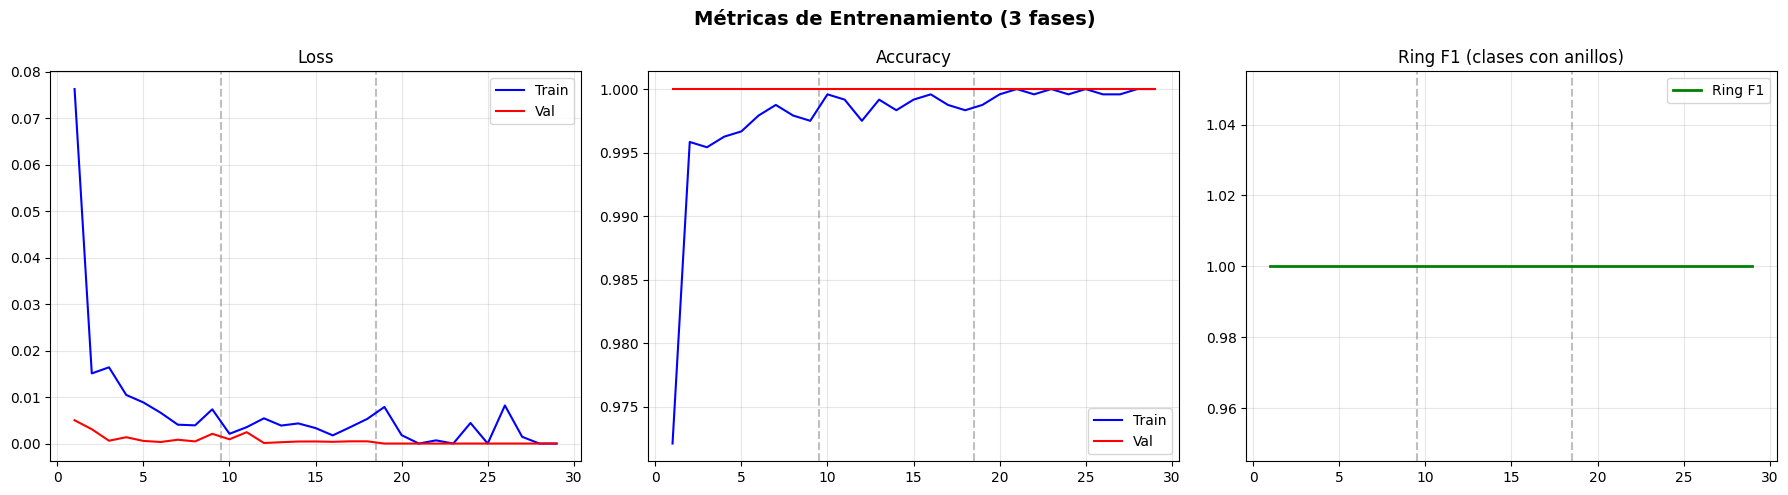

In [19]:
def plot_training_history(*histories, labels=None):
    all_train_loss, all_val_loss = [], []
    all_train_acc, all_val_acc, all_f1 = [], [], []
    for h in histories:
        all_train_loss.extend(h["train_loss"])
        all_val_loss.extend(h["val_loss"])
        all_train_acc.extend(h["train_acc"])
        all_val_acc.extend(h["val_acc"])
        all_f1.extend(h["ring_f1"])

    epochs = range(1, len(all_train_loss) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Phase boundaries
    phase_ends = []
    acc = 0
    for h in histories:
        acc += len(h["train_loss"])
        phase_ends.append(acc)

    for ax in axes:
        for pe in phase_ends[:-1]:
            ax.axvline(pe + 0.5, color='gray', linestyle='--', alpha=0.5)

    axes[0].plot(epochs, all_train_loss, 'b-', label='Train')
    axes[0].plot(epochs, all_val_loss, 'r-', label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, all_train_acc, 'b-', label='Train')
    axes[1].plot(epochs, all_val_acc, 'r-', label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, all_f1, 'g-', linewidth=2, label='Ring F1')
    axes[2].set_title('Ring F1 (clases con anillos)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Métricas de Entrenamiento (3 fases)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history_f1, history_f2, history_f3)

## 9.5 Evaluación final del modelo

Cargando: best_zoobot_v7_phase3_f1100.pt
Modelo cargado: best_zoobot_v7_phase3_f1100.pt (threshold=0.01)

Best threshold: 0.01
Ring F1: 1.0000

              precision    recall  f1-score   support

        none       1.00      1.00      1.00       300
        ring       1.00      1.00      1.00       265

    accuracy                           1.00       565
   macro avg       1.00      1.00      1.00       565
weighted avg       1.00      1.00      1.00       565



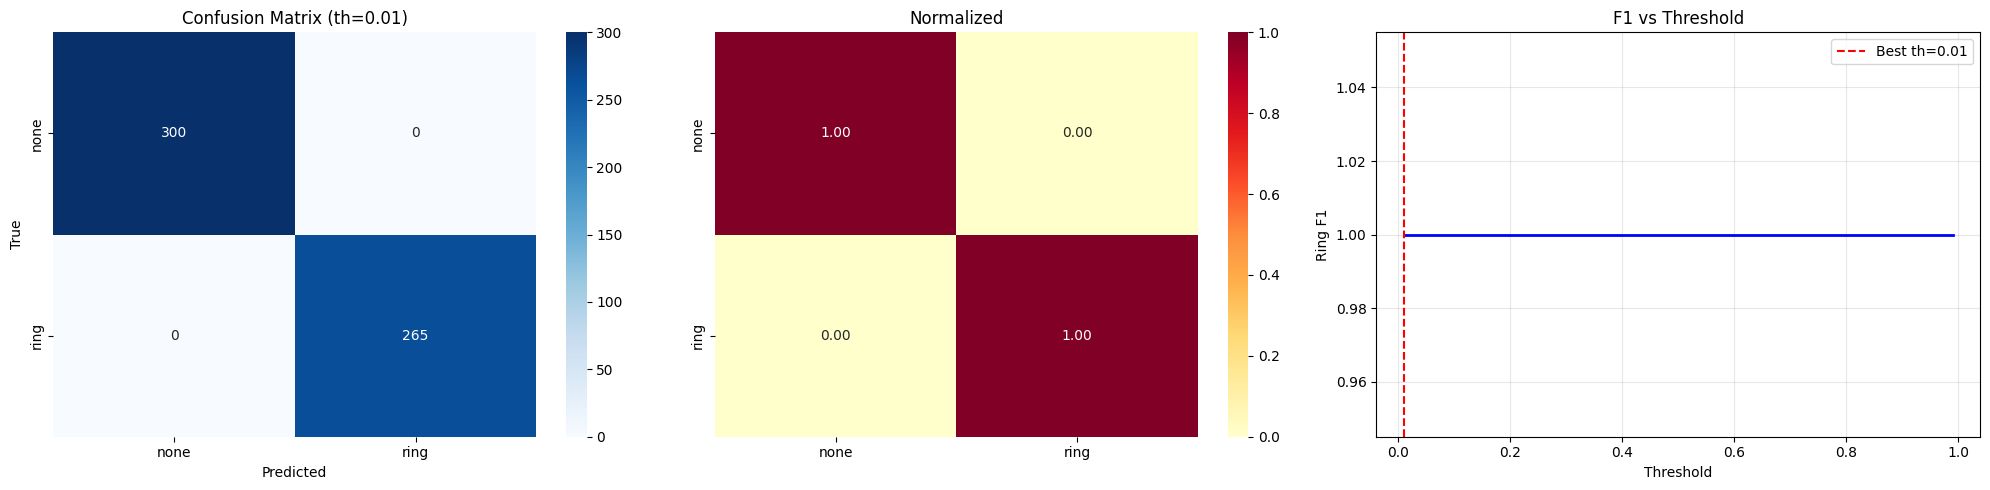


  Weighted F1: 1.0000
  Ring F1:     1.0000
  Threshold:   0.01


In [20]:
# Cargar mejor modelo y evaluar
import glob as glob_mod
best_models = sorted(glob_mod.glob("best_zoobot_v7_*.pt"))
if best_models:
    print(f"Cargando: {best_models[-1]}")
    model.load_model(best_models[-1])

report = model.evaluate(val_dataloader, plot=True)

# Resumen
wf1 = report['weighted avg']['f1-score']
rf1 = report['ring']['f1-score']
print(f"\n{'='*40}")
print(f"  Weighted F1: {wf1:.4f}")
print(f"  Ring F1:     {rf1:.4f}")
print(f"  Threshold:   {model.best_threshold:.2f}")
print(f"{'='*40}")


---
# Parte 10: Inferencia


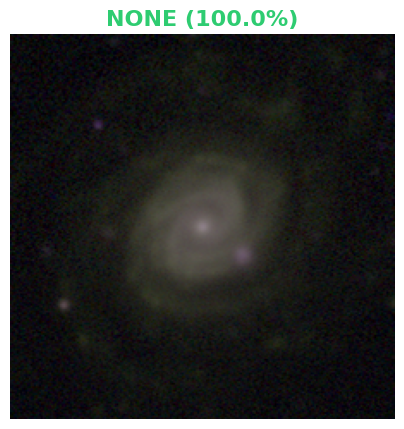

  → {'class': 'none', 'ring_prob': 1.5768238104119092e-10, 'threshold': np.float64(0.01)}


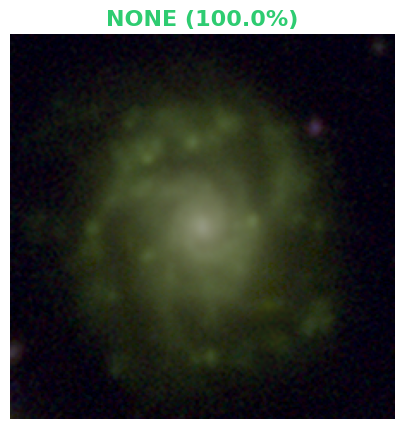

  → {'class': 'none', 'ring_prob': 8.755646901947856e-11, 'threshold': np.float64(0.01)}


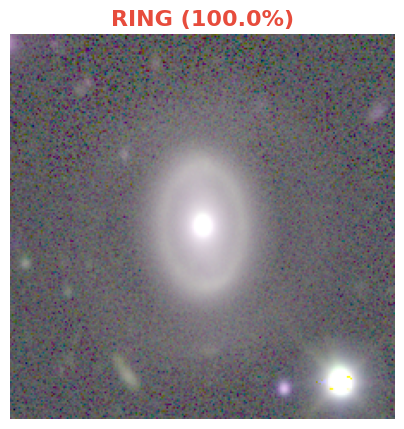

  → {'class': 'ring', 'ring_prob': 1.0, 'threshold': np.float64(0.01)}


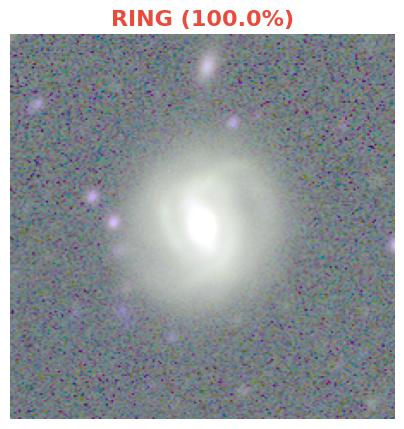

  → {'class': 'ring', 'ring_prob': 1.0, 'threshold': np.float64(0.01)}


In [21]:
def predict_galaxy(model, img_path, show=True):
    """Predice si una galaxia tiene anillo."""
    model.eval()
    img = Image.open(img_path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(model.device)
    
    with torch.no_grad():
        logit = model(tensor)
        prob = torch.sigmoid(logit).item()
    
    pred = "ring" if prob >= model.best_threshold else "none"
    conf = prob if pred == "ring" else 1 - prob
    
    if show:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(img)
        color = '#e74c3c' if pred == 'ring' else '#2ecc71'
        ax.set_title(f"{pred.upper()} ({conf:.1%})", fontsize=16, fontweight='bold', color=color)
        ax.axis("off")
        plt.show()
    
    return {"class": pred, "ring_prob": prob, "threshold": model.best_threshold}

# Probar
for cls_name in RING_TYPE:
    cls_dir = DATA_DIR / cls_name
    imgs = sorted(cls_dir.glob("*.png"))
    if imgs:
        for sample in random.sample(imgs, min(2, len(imgs))):
            result = predict_galaxy(model, sample)
            print(f"  → {result}")


---
# Parte 11: Exportar


In [22]:
final_path = OUTPUT_DIR / "zoobot_binary_v7_final.pt"
model.save_model(str(final_path))
print(f"Exportado: {final_path}")


Modelo guardado: outputs\zoobot_binary_v7_final.pt
Exportado: outputs\zoobot_binary_v7_final.pt
